In [27]:
library(data.table)
library(ggplot2)
library(qvalue)

In [10]:
saige_dir = '/directflow/SCCGGroupShare/projects/anncuo/TenK10K_pilot/tenk10k/eqtl_results/saige_qtl/december24_freeze/'
celltypes = list.files(saige_dir)
celltypes = celltypes[!(celltypes %in% c('README.md','CD4_TCM_sample_perm0','annotate','coloc_results'))]
length(celltypes)
celltypes

[1] 28

[1] "ASDC"              "B_intermediate"    "B_memory"         
 [4] "B_naive"           "CD14_Mono"         "CD16_Mono"        
 [7] "CD4_CTL"           "CD4_Naive"         "CD4_Proliferating"
[10] "CD4_TCM"           "CD4_TEM"           "CD8_Naive"        
[13] "CD8_Proliferating" "CD8_TCM"           "CD8_TEM"          
[16] "cDC1"              "cDC2"              "dnT"              
[19] "gdT"               "HSPC"              "ILC"              
[22] "MAIT"              "NK"                "NK_CD56bright"    
[25] "NK_Proliferating"  "pDC"               "Plasmablast"      
[28] "Treg"

In [34]:
df_list = list()
for (celltype in celltypes){
    rare_set_file = paste0(saige_dir,celltype,'/',celltype,'_all_cis_rv_set_test_results.tsv')
    rare_set_df = as.data.frame(fread(rare_set_file))
    df = rare_set_df
#     df = rare_set_df[rare_set_df$Group == "Cauchy",]
    df <- df[rowSums(is.na(df)) != ncol(df), ]
    df$celltype = celltype
    df_list[[celltype]] = df
}
df_rv = as.data.frame(rbindlist(df_list))
nrow(df_rv)
head(df_rv,2)

[1] 1608780

,Region,Group,min_MAF,max_MAF,Weight,Pvalue,Pvalue_ACATV,Pvalue_SKATO,Pvalue_Burden,Pvalue_SKAT,BETA_Burden,SE_Burden,MAC,Number_rare,Number_ultra_rare,celltype
,<chr>,<chr>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>
1,ENSG00000000457,null,0,0.01,dTSS,0.8620830,0.2982102,NA,0.9560128,0.5095483,0.0071022921,0.0020813415,3871.507,766,1502,ASDC
2,ENSG00000000457,null,0,0.01,Beta_1_25,0.6224634,0.2879813,NA,0.8439129,0.5403471,0.0008520751,0.0004215395,4063.000,766,1502,ASDC


In [46]:
df = df_rv
df_to_plot = data.frame()
for (celltype in celltypes){
    df0 = df[df$celltype == celltype & df$Weight == "Equal_Weights",]
    df0 <- df0[rowSums(is.na(df0)) != ncol(df0), ]
    df1 = df[df$celltype == celltype & df$Weight == "Beta_1_25",]
    df1 <- df1[rowSums(is.na(df1)) != ncol(df1), ]
    df2 = df[df$celltype == celltype & df$Weight == "dTSS",]
    df2 <- df2[rowSums(is.na(df2)) != ncol(df2), ]
    df3 = df[df$celltype == celltype & df$Group == "Cauchy",]
    df3 <- df3[rowSums(is.na(df3)) != ncol(df3), ]
    df0$qv = qvalue(df0$Pvalue)$qvalues
    df1$qv = qvalue(df1$Pvalue)$qvalues
    df2$qv = qvalue(df2$Pvalue)$qvalues
    df3$qv = qvalue(df3$Pvalue)$qvalues
    new_df0 = data.frame(celltype = celltype,
                         weight = "equal_weights",
                         n = nrow(df0[df0$qv < 0.05,]))
    new_df1 = data.frame(celltype = celltype,
                         weight = "beta_1_25",
                         n = nrow(df1[df1$qv < 0.05,]))
    new_df2 = data.frame(celltype = celltype,
                         weight = "dTSS",
                         n = nrow(df2[df2$qv < 0.05,]))
    new_df3 = data.frame(celltype = celltype,
                         weight = "all",
                         n = nrow(df3[df3$qv < 0.05,]))
    df_to_plot = rbind(df_to_plot, new_df0, new_df1, new_df2,new_df3)
}
df_to_plot$celltype_weight = paste0(df_to_plot$celltype,"-",df_to_plot$weight)
head(df_to_plot)

,celltype,weight,n,celltype_weight
,<chr>,<chr>,<int>,<chr>
1,ASDC,equal_weights,3971,ASDC-equal_weights
2,ASDC,beta_1_25,3977,ASDC-beta_1_25
3,ASDC,dTSS,3913,ASDC-dTSS
4,ASDC,all,3851,ASDC-all
5,B_intermediate,equal_weights,3077,B_intermediate-equal_weights
6,B_intermediate,beta_1_25,3105,B_intermediate-beta_1_25


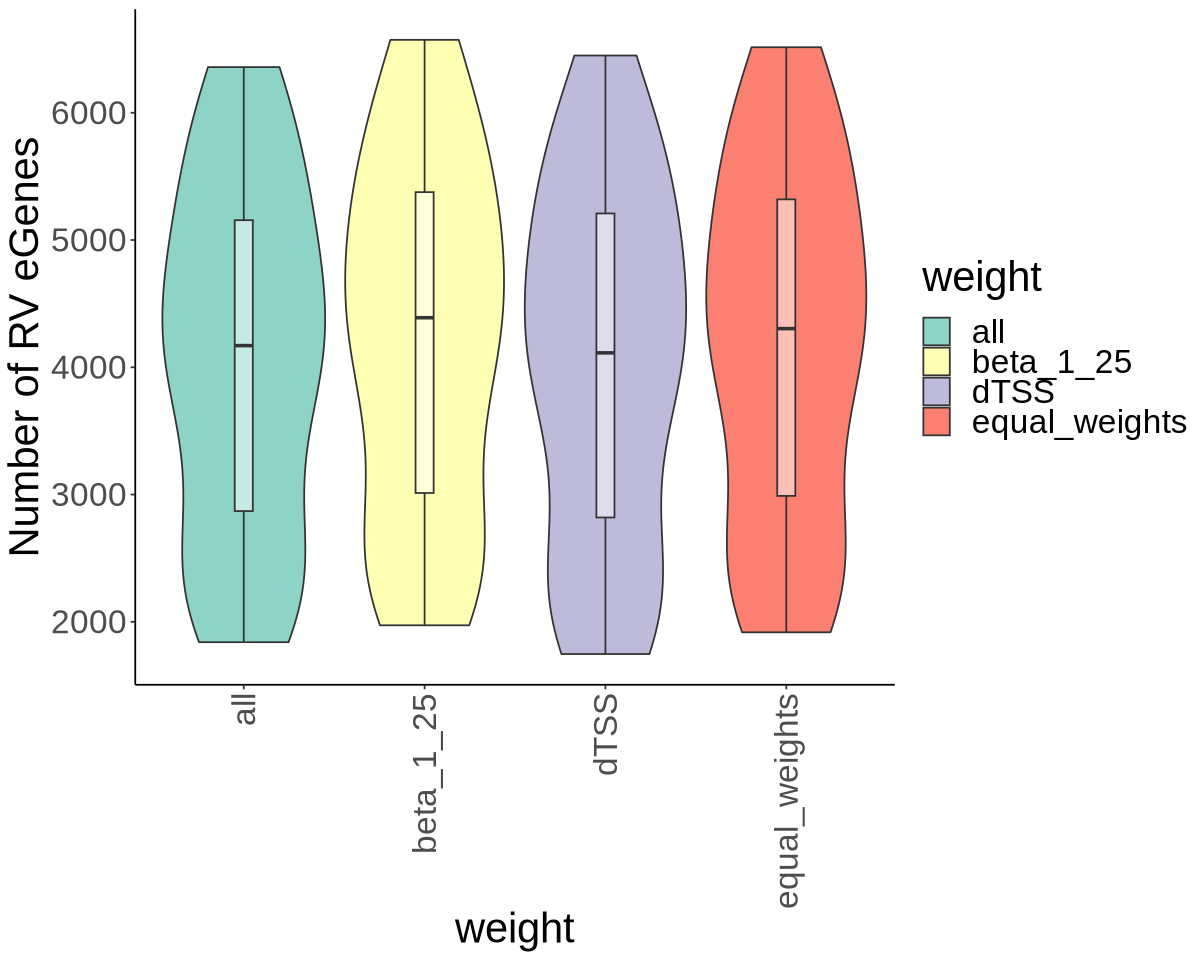

In [47]:
options(repr.plot.width = 10, repr.plot.height = 8) 
p = ggplot(df_to_plot, aes(x=weight, y=n, fill=weight)) + geom_violin() 
p = p + geom_boxplot(width=0.1, fill='white', alpha=0.5)
p = p + scale_fill_brewer(palette = "Set3") + theme_classic() 
p = p + theme(text = element_text(size=25), axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1),)
p + ylab('Number of RV eGenes')